## 1. Import Required Libraries

In this section, the necessary Python libraries are imported. These libraries are used for data manipulation, visualization, preprocessing, model training, and performance evaluation.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 2. Load the Dataset

The dataset is loaded into a pandas DataFrame. This dataset contains customer-related information and the target variable `Churn`, which indicates whether the customer left the service or not.

In [29]:
df = pd.read_csv('/content/Telco_Customer_Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Explore the Dataset

Before preprocessing, it is important to understand the structure of the dataset. This includes checking:
- number of rows and columns
- column names
- data types
- missing values

In [30]:
print("Shape of dataset:", df.shape)
print("\nColumns in dataset:")
print(df.columns.tolist())

Shape of dataset: (7043, 21)

Columns in dataset:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [32]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## 4. Check the Target Variable

The target variable in this dataset is `Churn`. This section checks the distribution of churned and non-churned customers.

In [33]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


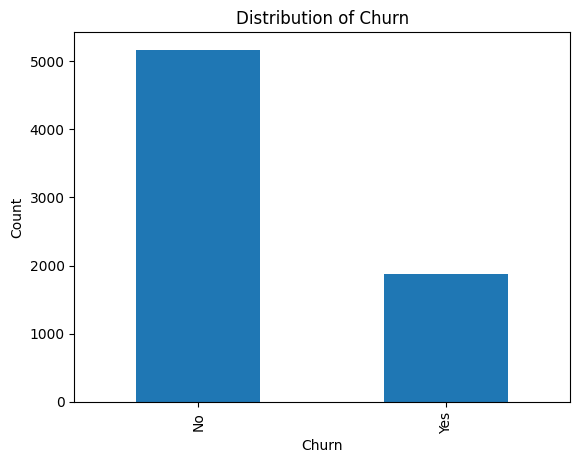

In [34]:
df['Churn'].value_counts().plot(kind='bar')
plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

## 5. Data Preprocessing

Data preprocessing is a critical step before model training. The following steps are performed:

1. Remove irrelevant columns
2. Convert data types if necessary
3. Handle missing values
4. Encode categorical variables into numerical form

### 5.1 Remove Unnecessary Columns

The `customerID` column does not contribute to prediction, so it is removed.

In [35]:
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 5.2 Convert `TotalCharges` to Numeric

The `TotalCharges` column may contain values stored as text. Therefore, it is converted into numeric format. Invalid values are replaced with missing values.

In [36]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

### 5.3 Handle Missing Values

Any missing values in the dataset are identified and handled. For numerical columns, missing values are filled using the median.

In [37]:
print(df.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [38]:
df = df.fillna(df.median(numeric_only=True))
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### 5.4 Encode Categorical Variables

Machine learning models require numerical input. Therefore, categorical columns are converted into numerical values using Label Encoding.

In [39]:
label_encoders = {}

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## 6. Feature and Target Selection

The dataset is divided into:
- `X` = input features
- `y` = target variable (`Churn`)

In [40]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


## 7. Split the Dataset into Training and Testing Sets

The dataset is divided into training and testing sets:
- 80% for training
- 20% for testing

This allows the model to be evaluated on unseen data.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 19)
X_test shape: (1409, 19)
y_train shape: (5634,)
y_test shape: (1409,)


## 8. Feature Scaling

Although Decision Tree models do not require feature scaling, StandardScaler is applied here as part of the common preprocessing workflow used in this project.

In [42]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 9. Train the Decision Tree Classifier

A Decision Tree classifier is trained using the training dataset. The `random_state` parameter is used to ensure reproducibility.

In [43]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

## 10. Make Predictions

The trained model is used to predict churn values for the test dataset.

In [44]:
y_pred = dt_model.predict(X_test_scaled)
y_pred[:10]

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 1])

## 11. Evaluate Model Performance

The model is evaluated using the following metrics:
- Accuracy
- Precision
- Recall
- F1-score

These metrics provide a comprehensive understanding of classification performance.

In [45]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7260468417317246
Precision: 0.48346055979643765
Recall   : 0.5093833780160858
F1 Score : 0.4960835509138381


In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1036
           1       0.48      0.51      0.50       373

    accuracy                           0.73      1409
   macro avg       0.65      0.66      0.65      1409
weighted avg       0.73      0.73      0.73      1409



## 12. Confusion Matrix

A confusion matrix is used to visualize the performance of the classifier by comparing actual and predicted values.

In [47]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[833 203]
 [183 190]]


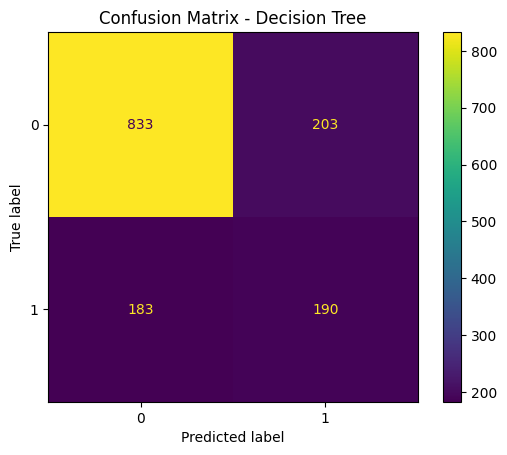

In [48]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

## 13. Decision Tree Visualization

The structure of the trained Decision Tree is visualized below. This helps in understanding how the model makes classification decisions.

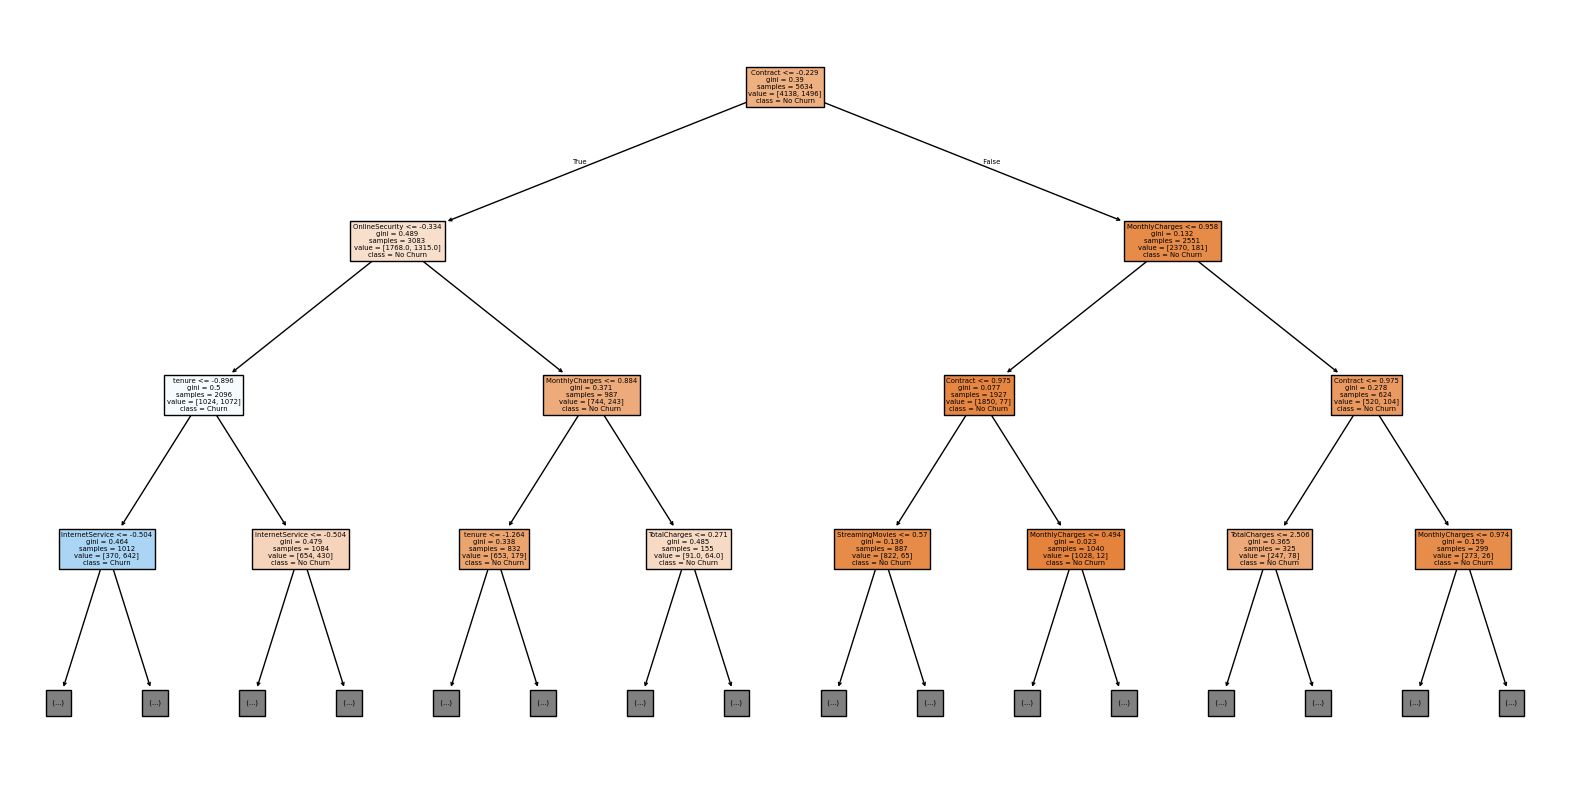

In [49]:
plt.figure(figsize=(20,10))
plot_tree(dt_model, filled=True, max_depth=3, feature_names=X.columns, class_names=['No Churn', 'Churn'])
plt.show()

## 14. Model Improvement by Hyperparameter Tuning

To improve the model, the `max_depth` parameter can be adjusted. Limiting tree depth may reduce overfitting and improve generalization.

In [50]:
depths = [3, 5, 7, 10, None]
results = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    results.append({
        "max_depth": depth,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1_score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
results_df

,max_depth,accuracy,precision,recall,f1_score
0,3.0,0.781405,0.631579,0.418231,0.503226
1,5.0,0.794180,0.605598,0.638070,0.621410
2,7.0,0.801987,0.649682,0.546917,0.593886
3,10.0,0.767211,0.559682,0.565684,0.562667
4,NaN,0.726047,0.483461,0.509383,0.496084


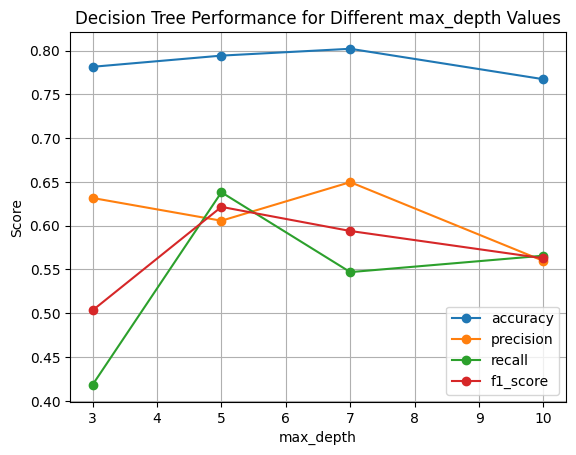

In [51]:
results_df.plot(x='max_depth', y=['accuracy', 'precision', 'recall', 'f1_score'], marker='o')
plt.title("Decision Tree Performance for Different max_depth Values")
plt.ylabel("Score")
plt.grid(True)
plt.show()

## 15. Train the Best Decision Tree Model

Based on the tuning results, the best-performing `max_depth` value is selected and used to train the final model.

In [52]:
best_dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
best_dt_model.fit(X_train_scaled, y_train)

best_y_pred = best_dt_model.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, best_y_pred))
print("Precision:", precision_score(y_test, best_y_pred))
print("Recall   :", recall_score(y_test, best_y_pred))
print("F1 Score :", f1_score(y_test, best_y_pred))

Accuracy : 0.794180269694819
Precision: 0.6055979643765903
Recall   : 0.6380697050938338
F1 Score : 0.6214099216710183


## 16. Interpretation of Results

The Decision Tree model was able to classify customer churn based on the available features in the dataset.

The model performance was evaluated using multiple classification metrics. The results indicate how effectively the model identifies churned and non-churned customers.

Hyperparameter tuning was also performed by adjusting the maximum depth of the tree. This helped analyze the effect of model complexity on performance.

## 17. Conclusion

In this notebook, a Decision Tree classifier was implemented for customer churn prediction. The workflow included data preprocessing, model training, prediction, and evaluation.

The Decision Tree algorithm is easy to interpret and suitable for classification tasks. However, its performance depends on parameter tuning, especially tree depth.

Overall, this model provides a useful approach for understanding customer churn behavior and can be compared with other machine learning algorithms used in the project.